In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Cargar datos y limpieza
df_cancer = pd.read_csv('breast-cancer.xls')
df_cancer = df_cancer.drop(columns=['id'])

# 2. Separar variables
X = df_cancer.drop(columns=['diagnosis'])
y = df_cancer['diagnosis']

# 3. Dividir datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Optimización con GridSearchCV (Búsqueda de hiperparámetros)
parametros = {'max_depth': [3, 4, 5, 6]}
arbol_base = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(arbol_base, parametros, cv=5)
grid.fit(X_train, y_train)

# 5. Evaluación del mejor modelo
mejor_arbol = grid.best_estimator_
y_pred = mejor_arbol.predict(X_test)

# 6. Imprimir Métricas
print(f"Mejor profundidad (max_depth): {mejor_arbol.max_depth}")
print(f"Precisión Global (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Mejor profundidad (max_depth): 4
Precisión Global (Accuracy): 0.95

Reporte de Clasificación:
              precision    recall  f1-score   support

           B       0.96      0.96      0.96       108
           M       0.94      0.94      0.94        63

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



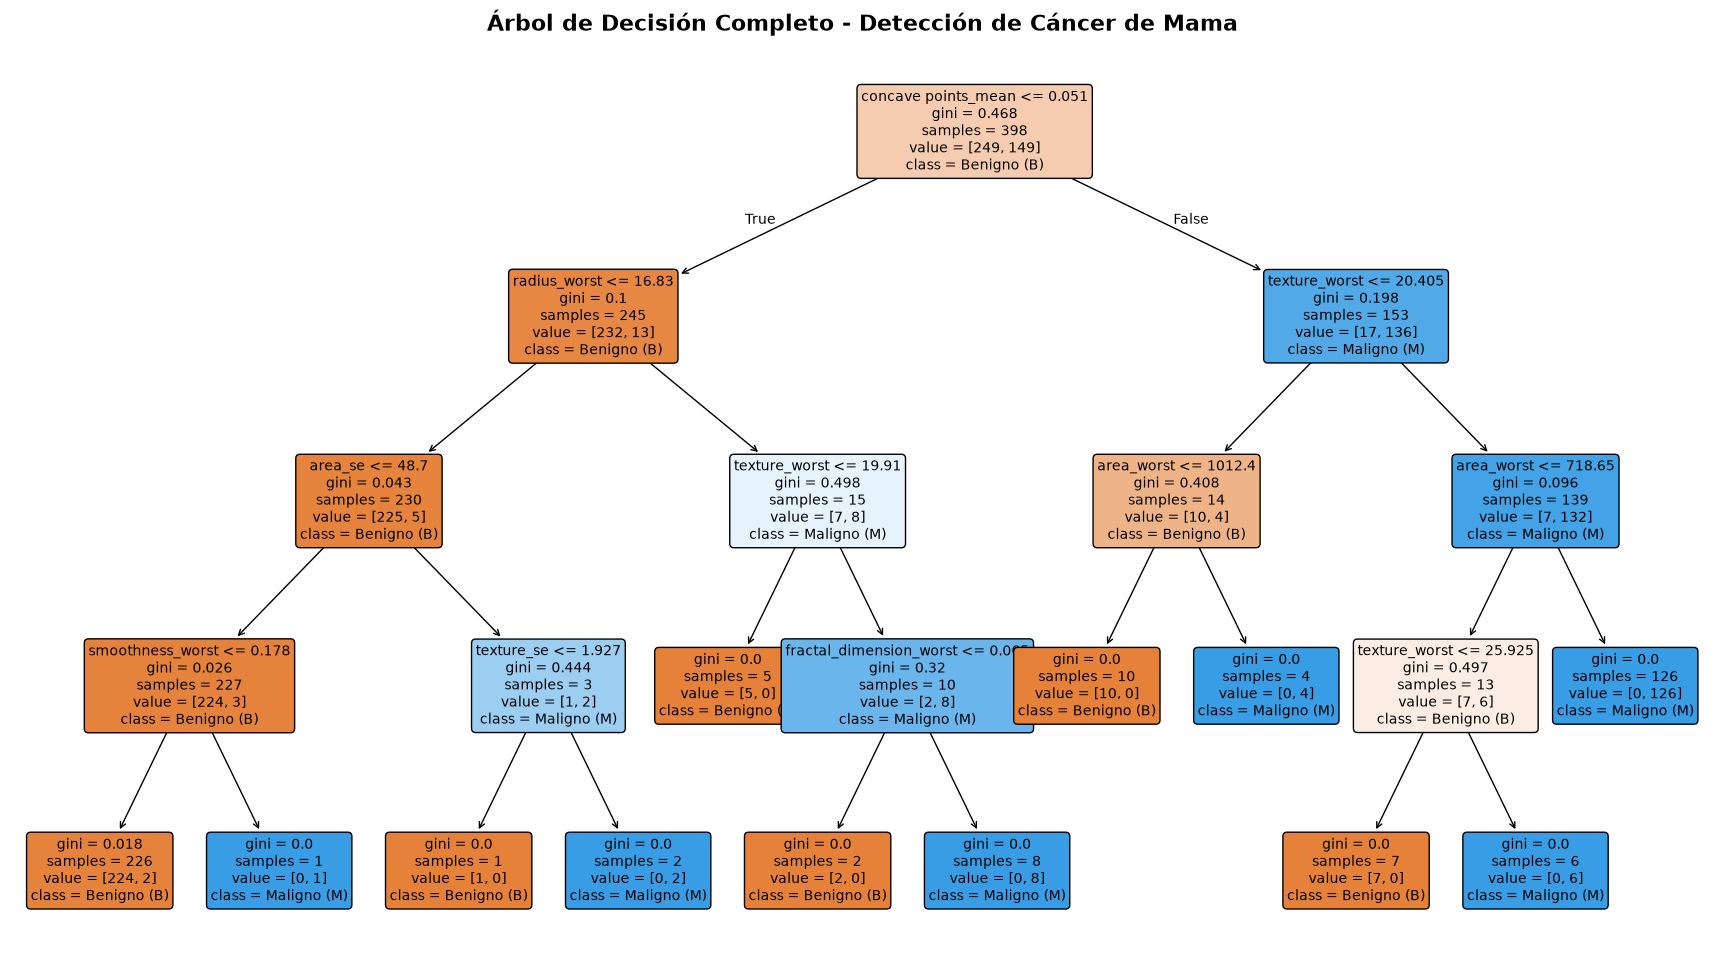

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 7. Dibujar la Gráfica del Árbol de Decisión completo
plt.figure(figsize=(22, 12))
plot_tree(mejor_arbol, 
          feature_names=X.columns, 
          class_names=['Benigno (B)', 'Maligno (M)'], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title('Árbol de Decisión Completo - Detección de Cáncer de Mama', fontsize=16, fontweight='bold')
plt.show()